## Customer Intelligence System using Customer Market Segmentation

### Week 3 Assignment – Classification, Ensemble Learning and Clustering

## 1. Project Overview

Every country has different economic and social conditions, which also affect customer behavior and market potential. In this project, each country is treated as a customer market. By grouping similar markets together, it becomes easier to understand where businesses can expand, target customers, and plan their strategies.

#### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

#### 3. Load Dataset

In [3]:
df = pd.read_csv("Country-data.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
df.info()
display(df.describe())

Dataset shape: (167, 10)

Columns:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


This dataset contains information about different countries, including income, GDP, health, inflation, and life expectancy. These features give an overall picture of each country's market condition and help identify similar customer markets.

#### 4. Data Cleaning

In [5]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

# Remove the duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

print("Missing values before cleaning:")
print(df.isnull().sum())

Shape after removing duplicates: (167, 10)
Missing values before cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [30]:
# Store country names separately
country_names = df["country"]

# Keeping only the feature columns
features_df = df.drop("country", axis=1)

# Converting all the feature columns to numeric
for col in features_df.columns:
    features_df[col] = pd.to_numeric(features_df[col], errors="coerce")

# Replace missing values with median
features_df = features_df.fillna(features_df.median())

print("Missing values after cleaning:")
print(features_df.isnull().sum())

Missing values after cleaning:
child_mort        0
exports           0
health            0
imports           0
income            0
inflation         0
life_expec        0
total_fer         0
gdpp              0
KMeans_Cluster    0
DBSCAN_Cluster    0
dtype: int64


Before starting the analysis, the dataset needs to be cleaned. Duplicate records, missing values, and incorrect data types can affect the clustering results, so these issues are handled first.

#### 5. Basic EDA

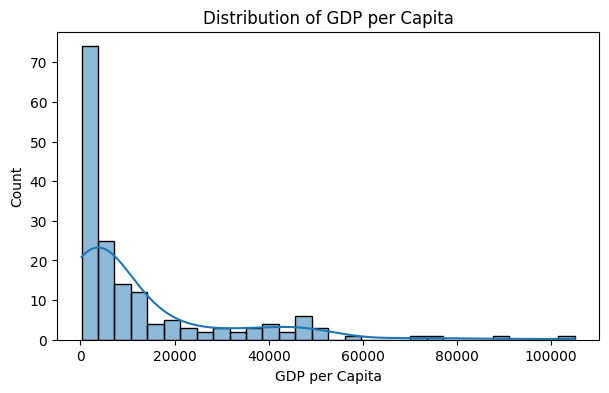

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(features_df["gdpp"], bins=30, kde=True)
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("Count")
plt.show()

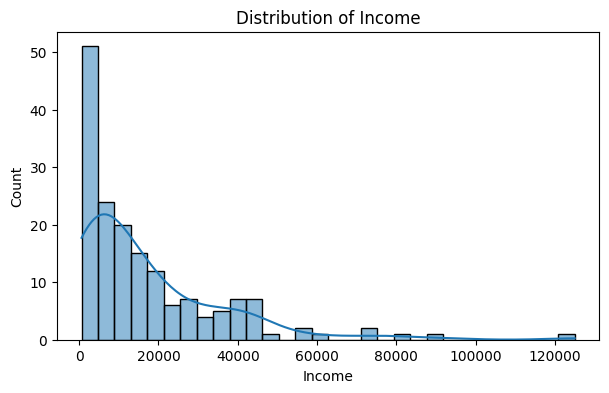

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(features_df["income"], bins=30, kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

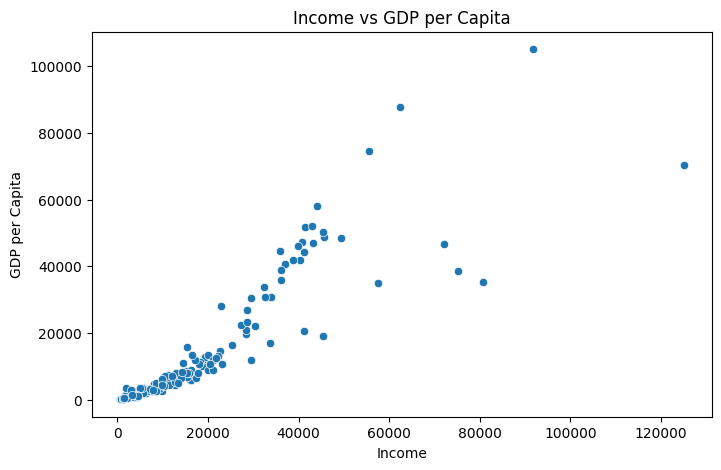

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=features_df["income"], y=features_df["gdpp"])
plt.title("Income vs GDP per Capita")
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.show()

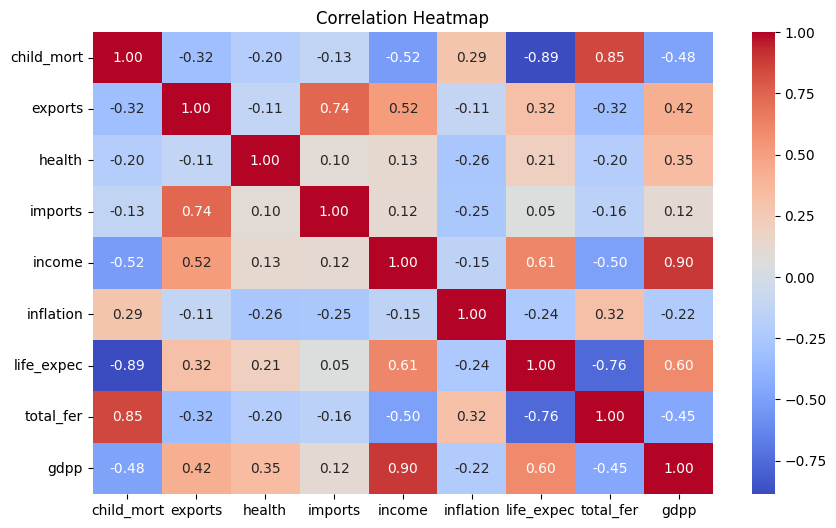

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(features_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Before building the clustering model, it is useful to understand how the data is distributed. The charts below show the relationship between different economic indicators and help identify useful patterns in the customer markets.

#### 6. Feature Scaling

In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features_df)
scaled_df = pd.DataFrame(scaled_data, columns=features_df.columns)
display(scaled_df.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


Features like GDP, income, and inflation have very different value ranges. If the data is not scaled, features with larger values can influence the clustering results more than others. StandardScaler helps give equal importance to every feature.

#### 7. Elbow Method

In [14]:
inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

print("Inertia values:")
for k, inertia in zip(k_values, inertia_values):
    print(f"k = {k}, Inertia = {inertia:.2f}")

Inertia values:
k = 2, Inertia = 1050.21
k = 3, Inertia = 831.42
k = 4, Inertia = 700.52
k = 5, Inertia = 620.16
k = 6, Inertia = 558.47
k = 7, Inertia = 495.81
k = 8, Inertia = 457.59
k = 9, Inertia = 427.80
k = 10, Inertia = 403.23


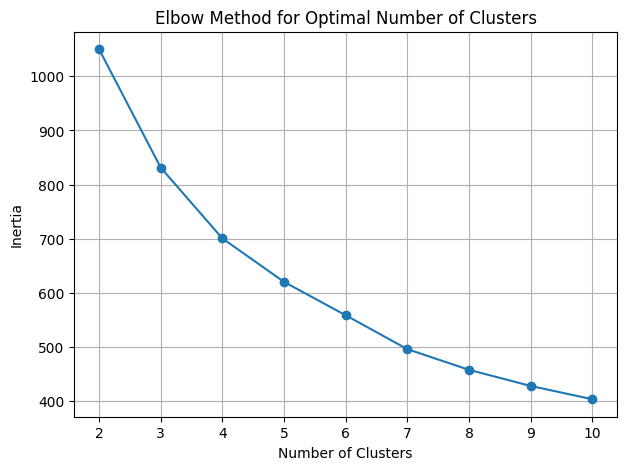

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

K-Means needs the number of clusters before training the model. Instead of choosing a random value, the Elbow Method helps find a suitable number by comparing the clustering error for different values of K.

#### 8. K-Means Clustering

In [17]:
best_k = 3
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(scaled_df)
df["KMeans_Cluster"] = kmeans_labels
print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


Countries with similar socio-economic conditions are grouped into the same cluster. This makes it easier to identify customer markets that share similar characteristics and business opportunities.

#### 9. Silhouette Score

In [19]:
sil_score = silhouette_score(scaled_df, kmeans_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.28329575683463126


After creating the clusters, the next step is to check how well they are formed. The Silhouette Score helps measure the quality of the clustering by showing how similar countries are within the same group compared to other groups.

#### 10. DBSCAN Clustering

In [20]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(scaled_df)
df["DBSCAN_Cluster"] = dbscan_labels
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


DBSCAN is used to compare the results with K-Means. It can also identify countries that do not belong to any major customer market segment, treating them as outliers.

#### 11. PCA Visualization

In [21]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = kmeans_labels
pca_df["Country"] = country_names.values
display(pca_df.head())

,PC1,PC2,Cluster,Country
0,-2.913025,0.095621,1,Afghanistan
1,0.429911,-0.588156,2,Albania
2,-0.285225,-0.455174,2,Algeria
3,-2.932423,1.695555,1,Angola
4,1.033576,0.136659,2,Antigua and Barbuda


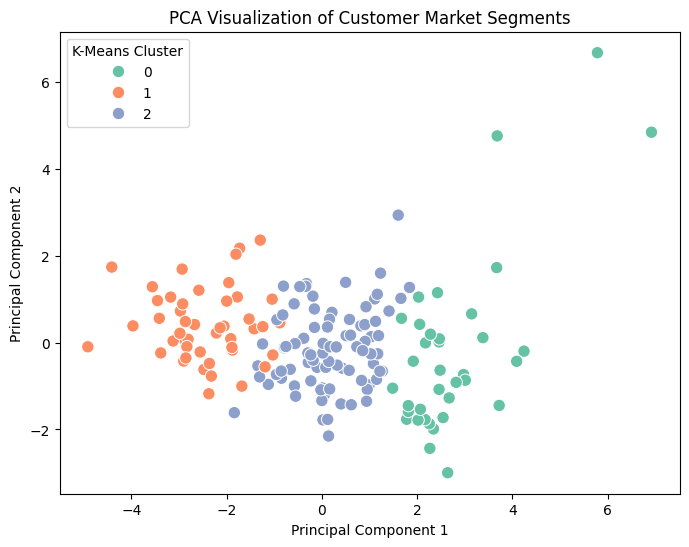

In [22]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("PCA Visualization of Customer Market Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.show()

Since the dataset has many features, it is difficult to visualize the clusters directly. PCA reduces the data into two dimensions, making it easier to see how the customer market segments are separated.

#### 12. Cluster Summary

In [23]:
cluster_summary = df.groupby("KMeans_Cluster")[features_df.columns].mean()
display(cluster_summary)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [26]:
cluster_country_count = df.groupby("KMeans_Cluster")["country"].count()
print("Number of countries in each cluster:")
print(cluster_country_count)

Number of countries in each cluster:
KMeans_Cluster
0    36
1    47
2    84
Name: country, dtype: int64


In [25]:
for cluster in sorted(df["KMeans_Cluster"].unique()):
    print(f"\nCluster {cluster} countries:")
    print(df[df["KMeans_Cluster"] == cluster]["country"].head(10).tolist())


Cluster 0 countries:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Cluster 1 countries:
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']

Cluster 2 countries:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']


Once the clusters are created, the average values of important features are compared. This gives a better understanding of how each customer market segment is different from the others.

#### 13. Identify Segment Types

In [28]:
display(cluster_summary[["child_mort", "income", "life_expec", "gdpp"]])

,child_mort,income,life_expec,gdpp
KMeans_Cluster,,,,
0,5.000000,45672.222222,80.127778,42494.444444
1,92.961702,3942.404255,59.187234,1922.382979
2,21.927381,12305.595238,72.814286,6486.452381


In [29]:
high_mortality_cluster = cluster_summary["child_mort"].idxmax()
top_economic_cluster = cluster_summary["gdpp"].idxmax()
low_development_cluster = cluster_summary["income"].idxmin()

print("High Mortality Cluster:", high_mortality_cluster)
print("Top Economic Zone Cluster:", top_economic_cluster)
print("Low Development Cluster:", low_development_cluster)

High Mortality Cluster: 1
Top Economic Zone Cluster: 0
Low Development Cluster: 1


Income, GDP, child mortality, and life expectancy are compared across all clusters. These indicators help identify high-value markets, developing markets, and lower-development markets.


### Customer Market Observations

• One customer market segment has higher income, GDP, and life expectancy. These countries have stronger purchasing power and are suitable for premium products.

• Another segment represents developing markets with moderate economic growth. These markets offer good opportunities for future expansion.

• The remaining segment has lower income and higher child mortality. Businesses entering these markets may need affordable products and long-term investment strategies.

## Final Conclusion

The customer markets were grouped into meaningful segments based on their socio-economic conditions. The results show clear differences between developed, developing, and lower-development markets. These insights can help businesses understand their customers better and make informed decisions for market expansion and targeting.

## What I Learned

- Learned how to prepare real-world data for clustering.
- Understood why feature scaling is important for distance-based algorithms.
- Used K-Means and DBSCAN to segment customer markets.
- Learned how PCA helps visualize high-dimensional data.
- Understood how clustering supports customer targeting and market analysis.